# B — Traditional Model: SIFT + BoVW + SVM

This notebook walks through our traditional baseline and shows the key results.
The actual implementation lives in `src/train_traditional.py` and
`src/predict_traditional.py` — this notebook imports from those files rather
than repeating the code, and focuses on the numbers and charts.

In [ ]:
import os

try:
    notebook_dir = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    notebook_dir = os.getcwd()

PROJECT_ROOT = os.path.dirname(notebook_dir)
os.chdir(PROJECT_ROOT)

import sys
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))

print("notebook file located at:", notebook_dir)
print("project root set to:", PROJECT_ROOT)
print("data/splits exists:", os.path.isdir(os.path.join(PROJECT_ROOT, "data", "splits")))
print("data/raw exists:", os.path.isdir(os.path.join(PROJECT_ROOT, "data", "raw")))

notebook file located at: e:\26T2\9517\group project\COMP9517-project\notebooks
project root set to: e:\26T2\9517\group project\COMP9517-project
data/splits exists: True
data/raw exists: True


## 1. SIFT + BoVW + SVM overview

Pipeline: extract SIFT keypoints/descriptors from each image → build a 512-word
visual vocabulary with k-means → encode each image as a BoVW histogram → classify
with an SVM (rbf kernel, C=10).

Full training took ~44 min, full prediction (clean + 15 robustness variants) took
~68 min — both were run once via the scripts below, and this notebook just loads
the results.

## 2. Dataset split loading

In [16]:
train_df = pd.read_csv("data/splits/train_paths.csv")
val_df = pd.read_csv("data/splits/val_paths.csv")
test_df = pd.read_csv("data/splits/test_paths.csv")

print(f"train: {len(train_df)} images, val: {len(val_df)}, test: {len(test_df)}")
print(f"classes: {train_df['class_idx'].nunique()}")
train_df.head()

train: 20000 images, val: 5000, test: 5000
classes: 500


,image_path,image_id,category_id,label,class_idx,split
0,data\raw\train_mini\00044_Animalia_Arthropoda_...,1193734,44,Trichonephila clavata,0,train
1,data\raw\train_mini\00044_Animalia_Arthropoda_...,2088407,44,Trichonephila clavata,0,train
2,data\raw\train_mini\00044_Animalia_Arthropoda_...,2057844,44,Trichonephila clavata,0,train
3,data\raw\train_mini\00044_Animalia_Arthropoda_...,1193967,44,Trichonephila clavata,0,train
4,data\raw\train_mini\00044_Animalia_Arthropoda_...,1233980,44,Trichonephila clavata,0,train


## 3. SIFT keypoint example

What the feature extraction step actually looks like on a real image.

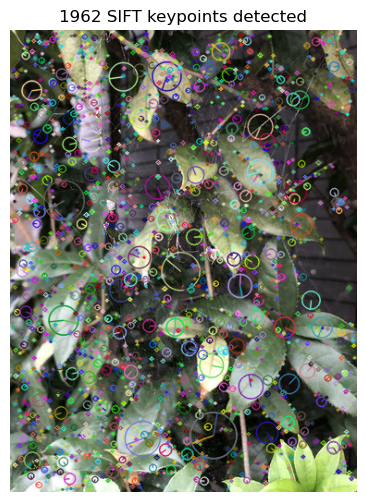

In [17]:
sift = cv2.SIFT_create()

sample_path = test_df.iloc[0]["image_path"]
img = cv2.imread(sample_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
keypoints, descriptors = sift.detectAndCompute(gray, None)

img_with_kp = cv2.drawKeypoints(
    img, keypoints, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_with_kp, cv2.COLOR_BGR2RGB))
plt.title(f"{len(keypoints)} SIFT keypoints detected")
plt.axis("off")
plt.show()

## 4. BoVW / SVM training settings

Vocabulary size and SVM hyperparameters were chosen by grid search on the
validation set (see `reports/SIFT_BoVW_SVM_dev_log.md` for the full experiment
log). Summary of that search:

In [18]:
vocab_search = pd.DataFrame([
    {"vocab_size": 128, "val_accuracy": 0.0714},
    {"vocab_size": 256, "val_accuracy": 0.0826},
    {"vocab_size": 512, "val_accuracy": 0.0890},
])
print("Vocabulary size search (SVM rbf, C=1.0):")
display(vocab_search)

svm_search = pd.DataFrame([
    {"kernel": "rbf", "C": 10, "val_accuracy": 0.1066},
    {"kernel": "rbf", "C": 100, "val_accuracy": 0.1066},
    {"kernel": "linear", "C": 10, "val_accuracy": 0.0938},
    {"kernel": "rbf", "C": 1, "val_accuracy": 0.0890},
    {"kernel": "linear", "C": 1, "val_accuracy": 0.0756},
    {"kernel": "rbf", "C": 0.1, "val_accuracy": 0.0542},
])
print("\nSVM hyperparameter search (vocab_size=512):")
display(svm_search.sort_values("val_accuracy", ascending=False))

print("\n=> final config: vocab_size=512, kernel=rbf, C=10")

Vocabulary size search (SVM rbf, C=1.0):


,vocab_size,val_accuracy
0,128,0.0714
1,256,0.0826
2,512,0.0890



SVM hyperparameter search (vocab_size=512):


,kernel,C,val_accuracy
0,rbf,10.0,0.1066
1,rbf,100.0,0.1066
2,linear,10.0,0.0938
3,rbf,1.0,0.0890
4,linear,1.0,0.0756
5,rbf,0.1,0.0542



=> final config: vocab_size=512, kernel=rbf, C=10


## 5. Quick live prediction with our trained model

Loading the actual trained vocabulary + SVM from `train_traditional.py`'s run,
and running a few real predictions using the same `encode_bovw` /
`extract_descriptors` functions from `predict_traditional.py`.

In [24]:
from predict_traditional import extract_descriptors, encode_bovw, load_models

kmeans, svm = load_models()

idx_to_name = dict(zip(train_df["class_idx"], train_df["label"]))

sample = test_df.sample(5, random_state=9517)

for _, row in sample.iterrows():
    from PIL import Image
    img = Image.open(row.image_path).convert("RGB")
    desc = extract_descriptors(img, sift)
    feat = encode_bovw(desc, kmeans, 512).reshape(1, -1)

    scores = svm.decision_function(feat)
    pred_idx = svm.classes_[np.argmax(scores)]

    true_name = idx_to_name[row.class_idx]
    pred_name = idx_to_name[pred_idx]
    mark = "correct" if pred_idx == row.class_idx else "wrong"
    print(f"[{mark}] true: {true_name:30s} pred: {pred_name}")

Loading vocabulary from results/models\traditional_kmeans_k512.pkl
Loading SVM from results/models\traditional_svm.pkl
[correct] true: Scarus ghobban                 pred: Scarus ghobban
[correct] true: Leucadendron salignum          pred: Leucadendron salignum
[wrong] true: Carduus pycnocephalus          pred: Myzinum quinquecinctum
[wrong] true: Helicoverpa armigera           pred: Sparassis spathulata
[wrong] true: Numenius americanus            pred: Platalea leucorodia


## 6. Clean test metrics

Full test set (5,000 images), from the official `predict_traditional.py` run.

,metric,value
0,top1_accuracy,0.107400
1,top5_accuracy,0.230400
2,macro_precision,0.104693
3,macro_recall,0.107400
4,macro_f1,0.098175


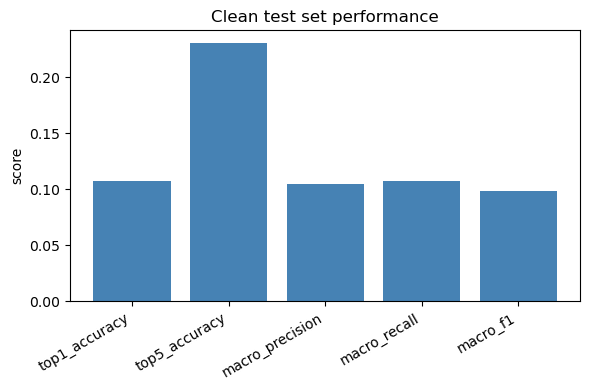

In [20]:
with open("results/clean/traditional_metrics.json") as f:
    clean_metrics = json.load(f)

metrics_to_show = ["top1_accuracy", "top5_accuracy", "macro_precision", "macro_recall", "macro_f1"]
metrics_df = pd.DataFrame([
    {"metric": m, "value": clean_metrics[m]} for m in metrics_to_show
])
display(metrics_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(metrics_df["metric"], metrics_df["value"], color="steelblue")
ax.set_ylabel("score")
ax.set_title("Clean test set performance")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 7. Robustness result

5 degradation types x 3 severities, all on the full 5,000-image test set.

,model,degradation,severity,top1_accuracy,top5_accuracy,macro_precision,macro_recall,macro_f1,metrics_json
0,traditional,clean,0.00,0.1074,0.2304,0.104693,0.1074,0.098175,results/clean/traditional_metrics.json
1,traditional,noise,0.05,0.0946,0.2218,0.098196,0.0946,0.086117,results/robustness/metrics/traditional_noise_0...
2,traditional,noise,0.10,0.0796,0.1884,0.080901,0.0796,0.068765,results/robustness/metrics/traditional_noise_0...
3,traditional,noise,0.20,0.0392,0.1042,0.053533,0.0392,0.031154,results/robustness/metrics/traditional_noise_0...
4,traditional,blur,3.00,0.0542,0.1494,0.072101,0.0542,0.049134,results/robustness/metrics/traditional_blur_3_...
5,traditional,blur,5.00,0.0212,0.0692,0.028758,0.0212,0.016658,results/robustness/metrics/traditional_blur_5_...
6,traditional,blur,7.00,0.0090,0.0326,0.004680,0.0090,0.004252,results/robustness/metrics/traditional_blur_7_...
7,traditional,brightness,0.40,0.0412,0.1148,0.074383,0.0412,0.040472,results/robustness/metrics/traditional_brightn...
8,traditional,brightness,0.60,0.0870,0.2006,0.103242,0.0870,0.082221,results/robustness/metrics/traditional_brightn...
9,traditional,brightness,0.80,0.1006,0.2272,0.100552,0.1006,0.092049,results/robustness/metrics/traditional_brightn...


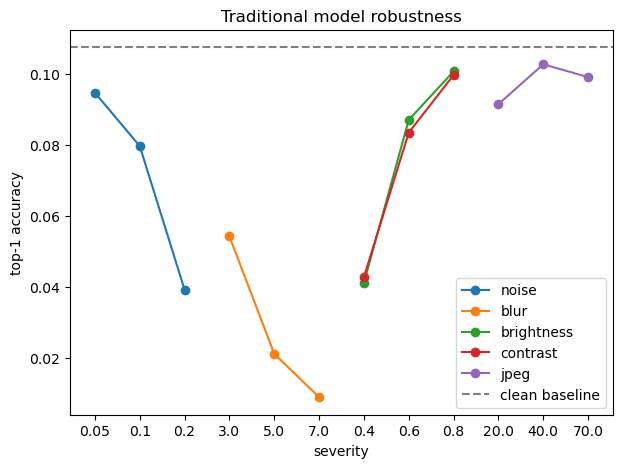

In [21]:
robust_df = pd.read_csv("results/robustness/combined_robustness_results.csv")
robust_df = robust_df[robust_df["model"] == "traditional"]
display(robust_df)

fig, ax = plt.subplots(figsize=(7, 5))
for deg in ["noise", "blur", "brightness", "contrast", "jpeg"]:
    sub = robust_df[robust_df["degradation"] == deg].sort_values("severity")
    ax.plot(sub["severity"].astype(str), sub["top1_accuracy"], marker="o", label=deg)

clean_acc = robust_df[robust_df["degradation"] == "clean"]["top1_accuracy"].values[0]
ax.axhline(clean_acc, color="gray", linestyle="--", label="clean baseline")

ax.set_xlabel("severity")
ax.set_ylabel("top-1 accuracy")
ax.set_title("Traditional model robustness")
ax.legend()
plt.show()

## 8. Short discussion

- Clean top-1 accuracy: ~10.7% on this 500-class fine-grained task — far above the
  0.2% random baseline, but this is a known limitation of hand-crafted features on
  fine-grained classification (this is exactly the comparison point against the
  deep learning models).
- **Blur is the most damaging degradation** (accuracy collapses to ~1% at the
  strongest level). SIFT relies on local edges/gradients to find keypoints, and
  blur destroys that structure directly.
- **JPEG compression barely matters** — SIFT keypoints tend to sit on strong,
  compression-resistant edges.
- Full engineering log (memory issues, hyperparameter search, timing) is in
  `reports/SIFT_BoVW_SVM_dev_log.md`.